In [140]:
import importlib
import pandas as pd
import numpy as np
import re
from pathlib import Path

import functions
importlib.reload(functions)
from functions import *

df_1111 = pd.read_csv("AI_Lit_Que_1111.csv")
df_1204 = pd.read_csv("AI_Lit_Que_1204.csv")

# add source/course label
df_1111["course"] = "1111"
df_1204["course"] = "1204"

print(df_1111.shape, df_1204.shape)


(118, 37) (23, 37)


In [71]:
# rename_map is defined in functions.py
df_1111 = df_1111.rename(columns=rename_map)
df_1204 = df_1204.rename(columns=rename_map)

df = pd.concat([df_1111, df_1204], ignore_index=True)


# Preprocessing

In [72]:
# clean_text, extract_leading_code, cronbach_alpha, add_combined_panel
# are defined in functions.py

df = df.applymap(clean_text)

# columns that should NOT go through leading-number extraction
exclude_from_numeric = {
    "id",
    "course",
    "ses_lang_cantonese",
    "ses_lang_mandarin",
    "ses_lang_english",
    "ses_lang_other",
}

special_attention_cols = {
    "ses_school_type",       # mostly nominal
    "ses_housing_type",      # not perfectly ordinal
    "ses_household_income",  # contains "Prefer not to say"
}

# extract from all remaining renamed questionnaire columns
numeric_source_cols = [
    col for col in df.columns
    if col not in exclude_from_numeric
]
for col in numeric_source_cols:
    df[col + "_num"] = df[col].apply(extract_leading_code)

# language columns should stay as binary indicators
language_cols = [
    "ses_lang_cantonese",
    "ses_lang_mandarin",
    "ses_lang_english",
    "ses_lang_other",
]
for col in language_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

-----
# EDA
## Descriptive statistics

### Mean comparison

#### SES

- Class 1111 is very slightly below the pooled SES average
- Class 1204 is slightly above the pooled SES average

The difference is present but not large in raw standardized units.

- *Skew < 0*: SES is somewhat left-skewed, especially in 1204.
  More observations are clustered on the higher side,
  with a tail toward lower SES-index values.

#### AI Literacy

- Class 1204 appears to have higher AI literacy on average than class 1111.
  The gap here is much more visible than for SES.


In [73]:
df, meta = prepare_dataset("AI_Lit_Que_1111.csv", "AI_Lit_Que_1204.csv")

construct_summary_table(df)

,sample,construct,n,mean,sd,median,iqr,skew
0,1111,SES index,118,-2.184274e-02,0.570420,0.003448,0.792470,-0.409507
1,1111,AI literacy score,118,3.490678e+00,0.409291,3.500000,0.500000,0.266702
2,1204,SES index,23,1.120627e-01,0.569433,0.235097,0.661270,-0.804122
3,1204,AI literacy score,23,3.800000e+00,0.450252,3.900000,0.750000,0.134169
4,Combined,SES index,141,-2.834612e-17,0.570388,0.020992,0.801864,-0.460321
5,Combined,AI literacy score,141,3.541135e+00,0.430128,3.500000,0.600000,0.294079


### Measurement consistency

#### SES

- SES shows **moderate** consistency across both classes
  (pooled Cronbach's α = 0.69).

#### AI Literacy

- AI literacy shows **low** consistency across both classes
  (pooled Cronbach's α = 0.52; even lower in 1111).

The AI literacy items do not appear to function as a highly homogeneous
single scale in this sample.


In [74]:
reliability_table(df, meta)

,sample,construct,alpha,n_complete
0,1111,SES index ingredients,0.689986,118
1,1111,AI literacy score,0.466021,118
2,1204,SES index ingredients,0.739366,23
3,1204,AI literacy score,0.624770,23
4,Combined,SES index ingredients,0.693905,141
5,Combined,AI literacy score,0.523376,141


### Effect sizes: Two-sided Mann–Whitney U test

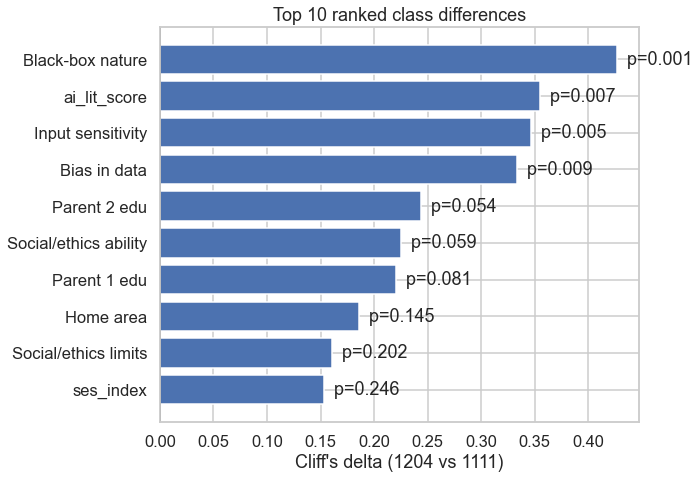

In [75]:
eff = effect_size_table(df, meta)
plot_ranked_effect_sizes(eff, top_n=10)

- Class 1204 tends to score higher than class 1111 on several AI literacy
  components, especially the more conceptual items.
- By contrast, the SES differences are weaker and mostly not statistically
  convincing.


## Visualizations
### Item profiles

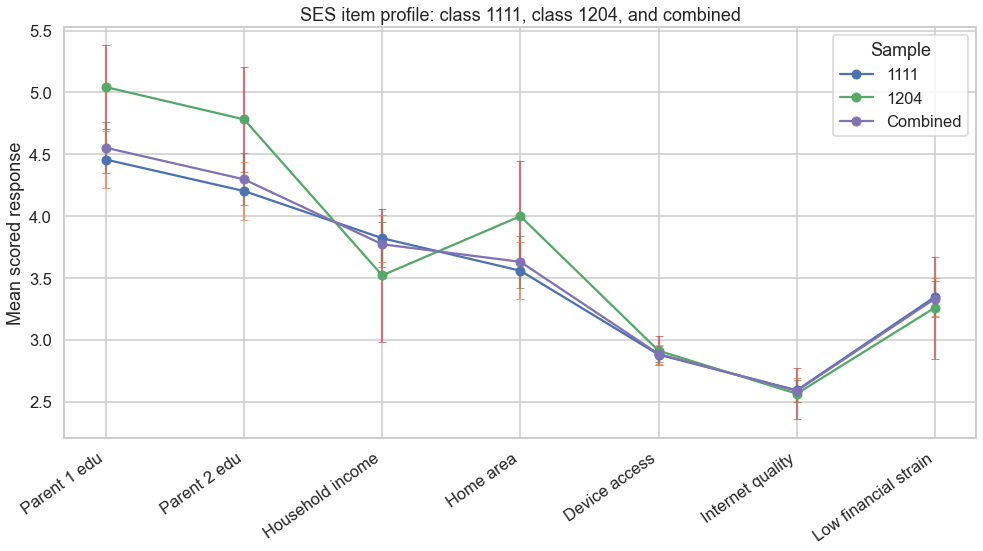

In [76]:
plot_item_profile(df, meta, construct="SES")

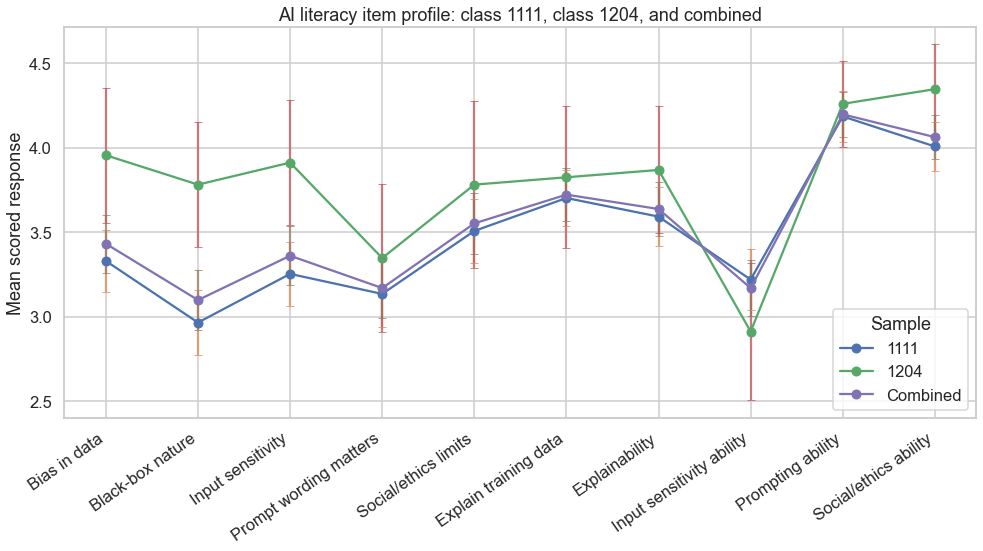

In [77]:
plot_item_profile(df, meta, construct="AI")

### Distribution of composite scores

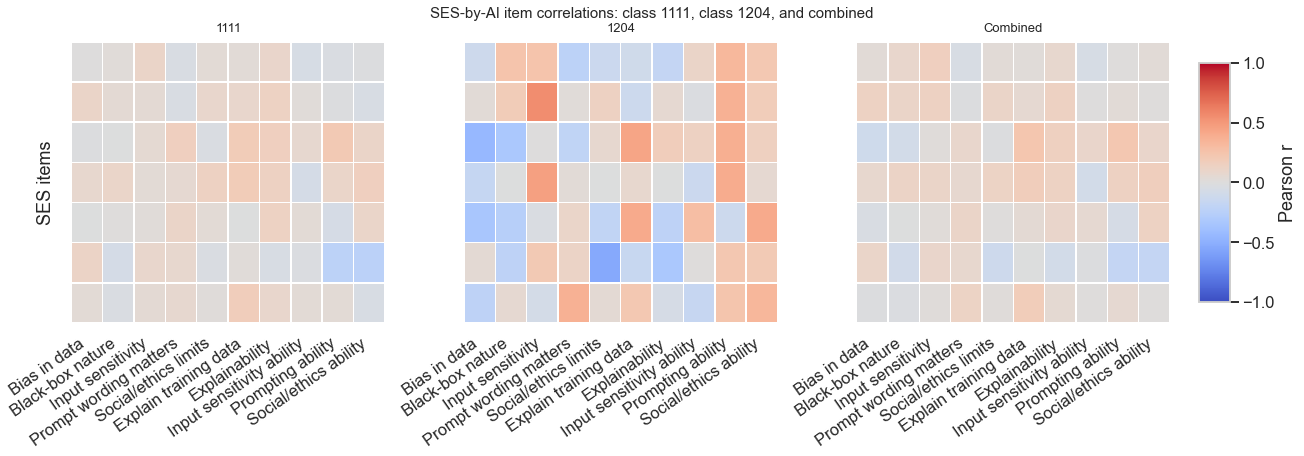

In [78]:
plot_ses_ai_correlation_heatmaps(df, meta)

- In the pooled sample, most correlations are weak to modest, with a tendency
  toward small positive associations rather than a single dominant pattern.
- The 1204 panel shows more extreme values, but given the much smaller
  subgroup size, those correlations are likely less stable.


-----
# SES Effect on AI Literacy (No mediation)

$$\text{AI literacy} = \beta_0 + \beta_1 \text{SES} + \varepsilon$$

In [79]:
def run_total_effect_models(df):
    results = []

    for sample in ["1111", "1204", "Combined"]:
        res, _, _ = fit_total_effect_model(df, sample=sample)
        results.append(res)

    return pd.concat(results, ignore_index=True)

run_total_effect_models(df)

,sample,n,beta_ses_std,se_hc3,t_hc3,p_hc3,ci_low_95,ci_high_95,r_squared,spearman_rho,spearman_p
0,1111,118,0.194558,0.084811,2.294033,0.021789,0.028333,0.360784,0.037853,0.199891,0.029991
1,1204,23,0.109333,0.270676,0.403926,0.686267,-0.421182,0.639848,0.011954,0.013161,0.952473
2,Combined,141,0.195893,0.076050,2.575846,0.010000,0.046838,0.344948,0.038374,0.201231,0.016723


- In the **combined sample**, SES shows a small but statistically supported
  positive association with AI literacy. Students with higher SES tend to
  have slightly higher AI literacy scores.
  
- In **class 1111**, the estimated SES effect is again positive and modest,
  and the result is statistically significant.
- In **class 1204**, the estimated effect is also positive, but highly
  uncertain and not statistically supported — most likely due to the much
  smaller sample size rather than evidence that no relationship exists.

The effect size is not large. In both 1111 and the combined sample, a one
standard deviation increase in SES is associated with only about a 0.2 SD
increase in AI literacy.

The explained variance is low (R² ≈ 0.04), meaning SES accounts for only a
small part of the variation in AI literacy. SES appears to matter, but is
clearly not the only factor.

- The Spearman correlations are also positive in 1111 and in the combined
  sample, supporting the same conclusion from a rank-based perspective.


## Exploratory Factor Analysis (EFA) for AI Literacy

In [83]:
ai_efa_items = [
    "ai_concept_data_bias_scored_num",
    "ai_concept_blackbox_scored_num",
    "ai_concept_input_variation_scored_num",
    "ai_concept_prompt_wording_scored_num",
    "ai_concept_social_ethics_scored_num",
    "ai_ability_training_data_scored_num",
    "ai_ability_explainability_scored_num",
    "ai_ability_input_sensitivity_scored_num",
    "ai_ability_prompting_scored_num",
    "ai_ability_social_ethics_scored_num",
]

diag_combined, kmo_items_combined = efa_diagnostics(df, "Combined", ai_efa_items)
diag_combined

,sample,n_complete,bartlett_chi2,bartlett_p,kmo_overall
0,Combined,141,245.646175,1.921883e-29,0.703442


- The diagnostics suggest that running EFA on the combined AI literacy items is reasonable

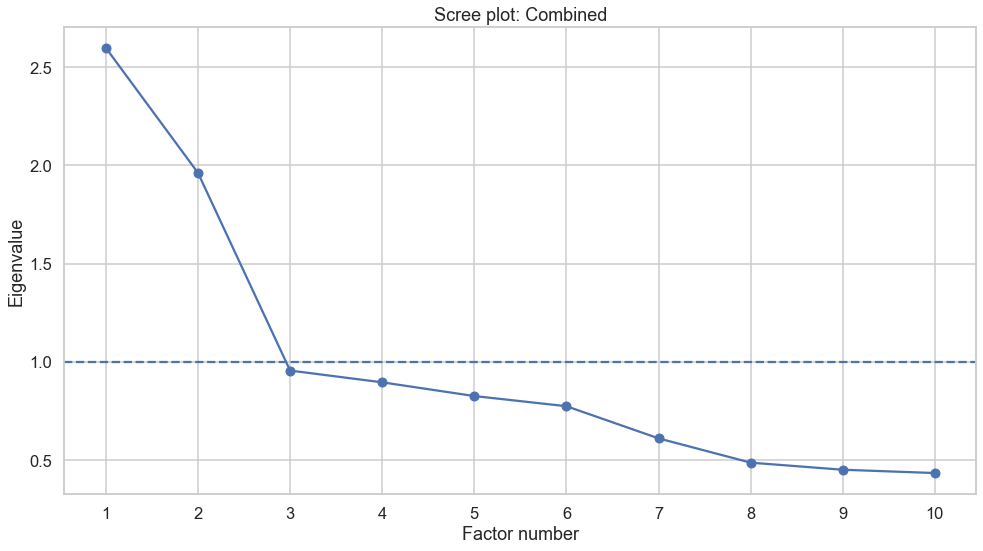

,factor_number,eigenvalue
0,1,2.598085
1,2,1.962121
2,3,0.956333
3,4,0.896443
4,5,0.826614
5,6,0.774900
6,7,0.611327
7,8,0.487682
8,9,0.451673
9,10,0.434821


In [96]:
eig_combined = run_scree_analysis(df, "Combined", ai_efa_items)
eig_combined

- The eigenvalues support a two-factor modeling. 2 principal components have eigenvalues > 1.

In [99]:
fa_combined, d_combined, loadings_combined, variance_combined = fit_efa(
    df=df,
    sample="Combined",
    items=ai_efa_items,
    n_factors=2,
    rotation="oblimin"
)

clean_loadings(loadings_combined, cutoff=0.30)


,Factor1,Factor2
ai_concept_data_bias_scored_num,0.624,
ai_concept_blackbox_scored_num,0.598,
ai_concept_input_variation_scored_num,0.44,
ai_concept_prompt_wording_scored_num,0.518,
ai_concept_social_ethics_scored_num,0.75,
ai_ability_training_data_scored_num,,0.505
ai_ability_explainability_scored_num,,0.454
ai_ability_input_sensitivity_scored_num,-0.416,
ai_ability_prompting_scored_num,,0.658
ai_ability_social_ethics_scored_num,,0.523


- *Factor 1 is dominated by the conceptual items*: data bias, black-box nature, input variation, prompt wording, and especially social/ethics limits all load positively on this factor. 

That means Factor 1 can be interpreted as something like conceptual AI understanding

- *Factor 2 is dominated by the self-reported competence items*: explaining training data, explainability, prompting ability, and social/ethics ability load on this factor.

Factor 2 looks like self-reported AI ability/confidence.



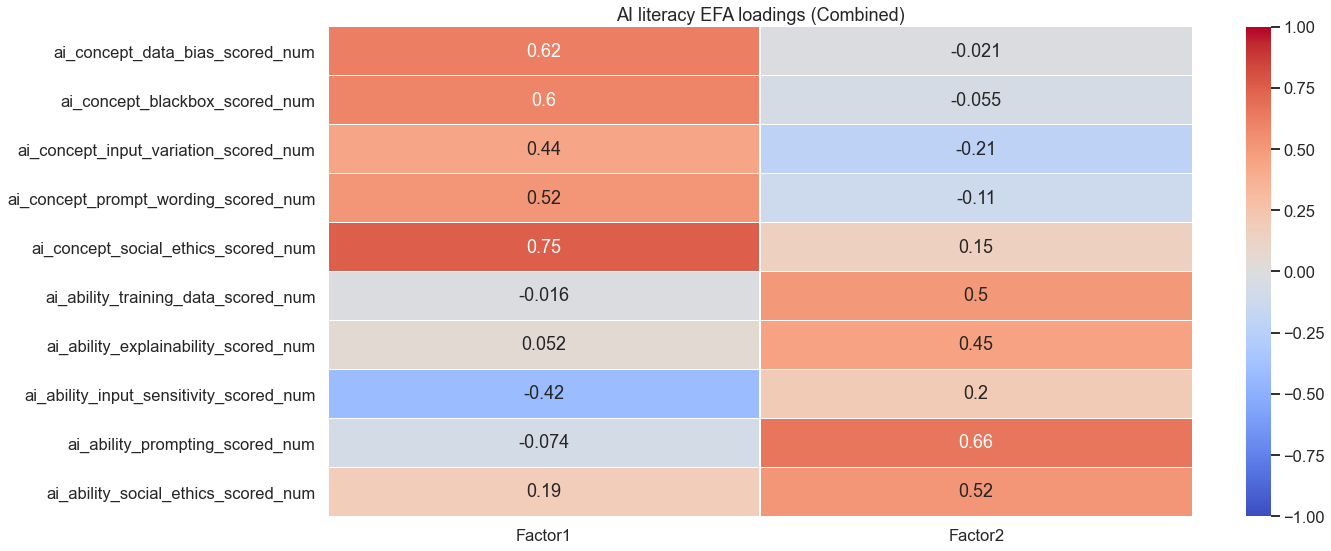

In [100]:
plot_loading_heatmap(
    loadings_combined,
    title="AI literacy EFA loadings (Combined)"
)

## EFA for SES (Ordinal variables only)

In [ ]:
# some non-ordinal variables are excluded here

ses_efa_items = [
    "ses_parent1_edu_num",
    "ses_parent2_edu_num",
    "ses_household_income_num",
    "ses_home_area_num",
    "ses_device_access_scored_num",
    "ses_internet_quality_scored_num",
    "ses_financial_constraint_scored_num",
]

diag_ses_combined, kmo_ses_combined = efa_diagnostics(df, "Combined", ses_efa_items)
diag_ses_combined

,sample,n_complete,bartlett_chi2,bartlett_p,kmo_overall
0,Combined,141,212.688137,1.135030e-33,0.647914


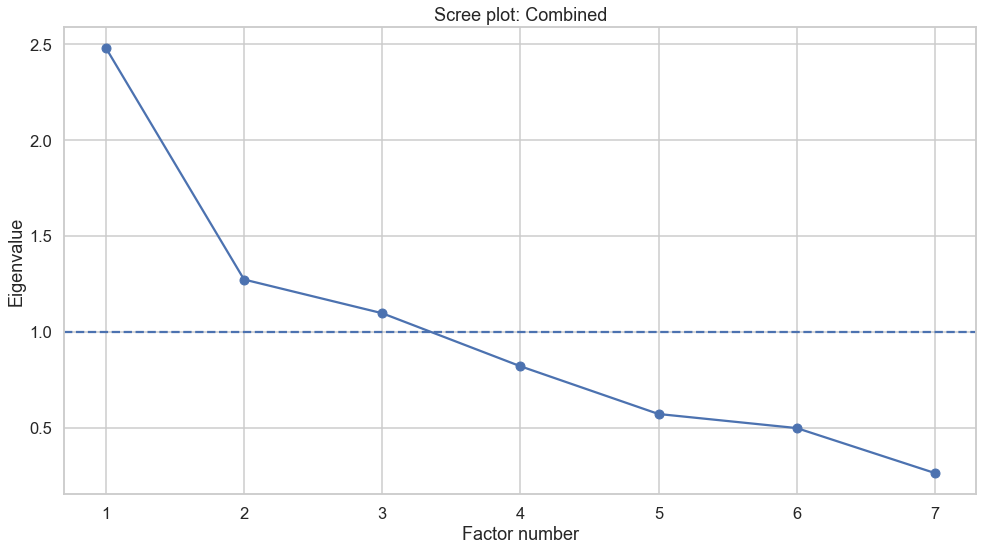

,factor_number,eigenvalue
0,1,2.480968
1,2,1.272444
2,3,1.096462
3,4,0.819858
4,5,0.570590
5,6,0.497186
6,7,0.262491


In [102]:
eig_ses_combined = run_scree_analysis(df, "Combined", ses_efa_items)
eig_ses_combined

In [112]:
fa_ses_1, d_ses_1, loadings_ses_1, variance_ses_1 = fit_efa(
    df=df,
    sample="Combined",
    items=ses_efa_items,
    n_factors=1,
    rotation=None
)


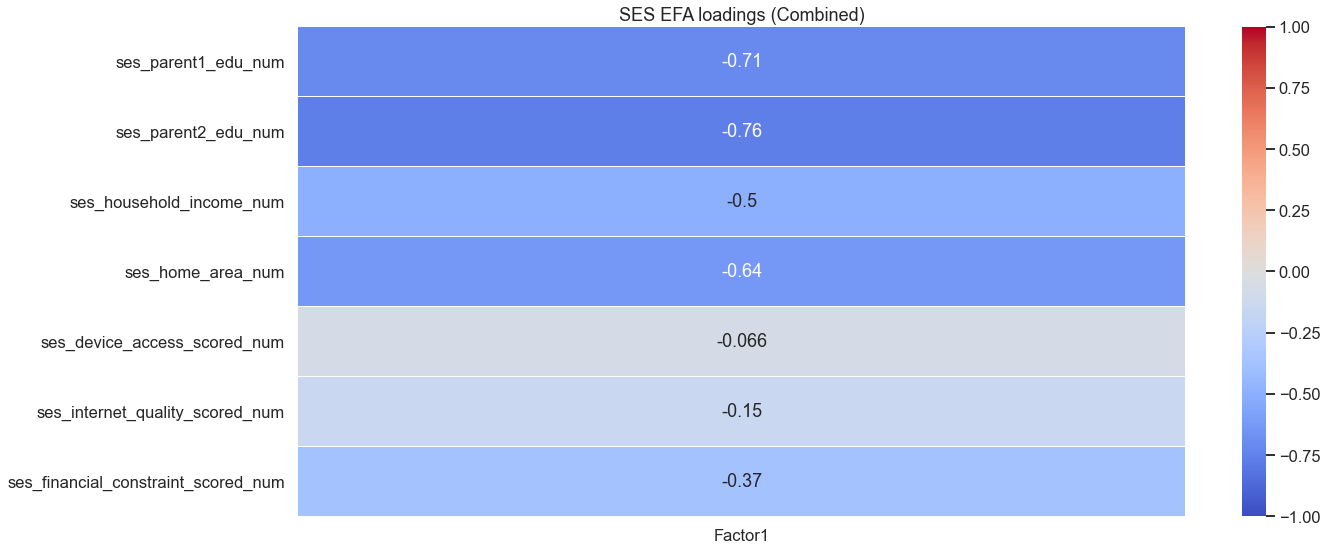

In [113]:
plot_loading_heatmap(loadings_ses_1, title="SES EFA loadings (Combined)", figsize=(20, 8))

- These items are moving together as one common dimension. Factor signs are arbitrary in EFA.

#### Conclusion
- Based on the EFA, SES can be treated as one broad underlying dimension, while AI literacy is better represented by two related but distinct components: conceptual understanding and ability/confidence. 

The excluded SES-related variables can be retained outside the main SES factor and incorporated later as separate covariates, subgroup variables, or sensitivity checks.

- Refiting the simple linear model using the factor scores:
It returns a disappointing result: the SES factor is not significantly associated with either AI factor, and the effect sizes are very small. 


# Mediators
## Mediator pairs

Each mediator is measured by two different questions. We should check the consistency of these pairs before using them in mediation analyses. 

In [129]:
mediator_reliability = mediator_reliability_table(df, mediator_map)
mediator_reliability

,sample,mediator,n_complete,spearman_rho,alpha_2item
0,1111,conceptual_exposure,118,0.292140,0.486054
1,1111,practical_ai_use,118,0.223236,0.379432
2,1111,learning_ecology,118,0.147209,0.274513
3,1111,language_load,118,0.601679,0.759845
4,1111,epistemic_stance,118,0.320206,0.564601
5,1204,conceptual_exposure,23,0.392293,0.567944
6,1204,practical_ai_use,23,0.367887,0.528373
7,1204,learning_ecology,23,0.399625,0.622269
8,1204,language_load,23,0.625154,0.779258
9,1204,epistemic_stance,23,0.360713,0.406300


- rho >= 0.30 , alpha > 0.5 means acceptable for a 2-item pair 

- Most pairs show at least a modest positive association (by rho and Alpha 2 )

- The weakest pair is learning_ecology (rho ≈ 0.18, p ≈ 0.028). 
This is still positive, but the association is fairly small. That suggests the two items may not be capturing exactly the same thing, even if they belong to the same broad domain.


#### Add composite mediator scores (averaging two items)

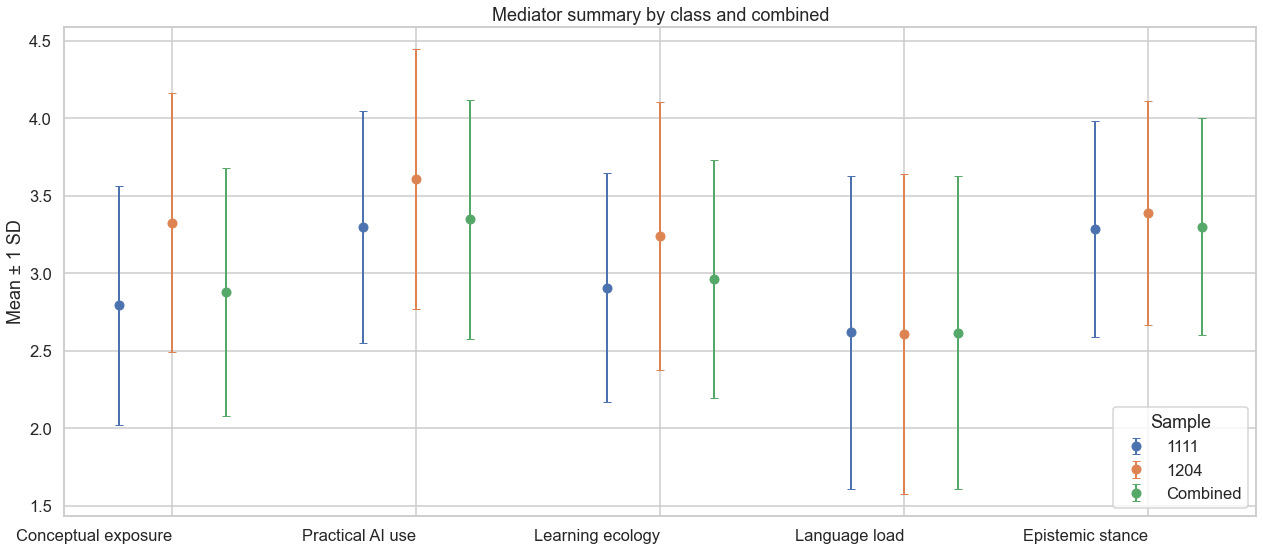

In [138]:
df_med = add_mediator_composites(df, mediator_map)
# mediators table
med_summary = mediator_summary_table(df_med)
plot_mediator_summary(med_summary, errorbar="sd")

# Mediation Analysis


In [ ]:
# merge factor scores into mediator dataframe
df_analysis = df_med.copy()

if "ai_factor1_score" in df_factors.columns and "ai_factor2_score" in df_factors.columns:
    df_analysis.loc[df_factors.index, "ai_factor1_score"] = df_factors["ai_factor1_score"]
    df_analysis.loc[df_factors.index, "ai_factor2_score"] = df_factors["ai_factor2_score"]

# Check the data
# df_analysis[["course", "ses_index", "ai_factor1_score", "ai_factor2_score"]].head()

mediator_vars = [
    "conceptual_exposure_score",
    "practical_ai_use_score",
    "learning_ecology_score",
    "language_load_score",     
    "epistemic_stance_score",
]

outcome_vars = [
    "ai_factor1_score",   # conceptual understanding
    "ai_factor2_score",   # ability/confidence
]

mediation_results = run_all_simple_mediations(
    df_analysis,
    x="ses_index",
    mediators=mediator_vars,
    outcomes=outcome_vars,
    n_boot=3000,
    seed=2026
)

label_map = {
    "conceptual_exposure_score": "Conceptual exposure",
    "practical_ai_use_score": "Practical AI use",
    "learning_ecology_score": "Learning ecology",
    "language_load_score": "Language load",   # or Language ease if reversed
    "epistemic_stance_score": "Epistemic stance",
    "ai_factor1_score": "AI conceptual understanding",
    "ai_factor2_score": "AI ability/confidence",
}

mediation_results["mediator"] = mediation_results["mediator"].map(label_map)
mediation_results["outcome"] = mediation_results["outcome"].map(label_map)

mediation_results.round(3)